In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
#df = pd.read_csv(r'C:\Users\chanhyeok\Desktop\lucky7\airbnb_price_prediction\data\df_cleaned.csv')
#df.head()

# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df = pd.read_csv('data/df_cleaned.csv')
df.head()

c:\Users\chanhyeok\Desktop\lucky7\airbnb_price_prediction


,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765.0,3,60,3.0,3.0,60.0,60.0,3.0,60.0,True,30,49,66,326,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,False,1,0,1,0,0.28,1,1,1,6.641182,0.000000
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,1.0,0.97,True,Harlem,1.0,1.0,True,True,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139.0,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,True,7,18,25,25,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,False,1,1,0,0,1.36,1,1,0,4.941642,10.475

# 호스트 관련

In [3]:
# 호스트 응답 시간 별 가격, 전체 리뷰 점수, 커뮤니케이션 리뷰 점수 평균
# nan을 포함해서 진행해봄


df_response_nan_cleaned = df.copy()
df_response_nan_cleaned['host_response_time'] = df_response_nan_cleaned['host_response_time'].fillna('NaN')

host_response_price_df = df_response_nan_cleaned.groupby('host_response_time').agg(
    mean_price=('price','mean'),
    mean_review_score=('review_scores_rating','mean'),
    mean_communication_score=('review_scores_communication','mean'),
    occupied_date = ('estimated_occupancy_l365d','mean')
)
host_response_price_df.round(2)

,mean_price,mean_review_score,mean_communication_score,occupied_date
host_response_time,,,,
NaN,226.77,4.74,4.85,15.83
a few days or more,163.12,4.58,4.59,25.97
within a day,171.09,4.75,4.82,55.34
within a few hours,177.64,4.76,4.84,83.31
within an hour,230.63,4.71,4.81,95.26


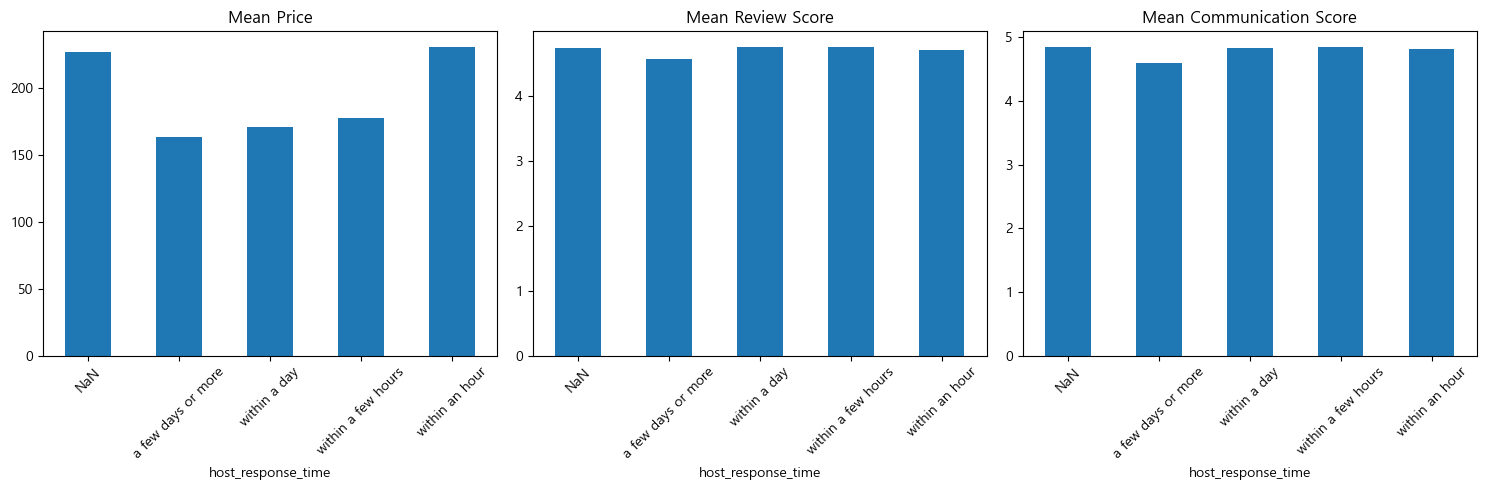

In [4]:
#막대그래프로 시각화
fig, axes = plt.subplots(1, 3, figsize=(15,5))

host_response_price_df['mean_price'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Mean Price')
axes[0].tick_params(axis='x', rotation=45)

host_response_price_df['mean_review_score'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean Review Score')
axes[1].tick_params(axis='x', rotation=45)

host_response_price_df['mean_communication_score'].plot(kind='bar', ax=axes[2])
axes[2].set_title('Mean Communication Score')
axes[2].tick_params(axis='x', rotation=45)



plt.tight_layout()
plt.show()

In [5]:
#가격과 호스트 관련 컬럼과의 상관관계
host_num_cols = ['host_response_rate','host_acceptance_rate','host_listings_count','host_total_listings_count']

price_host_cols = ['price','log_price'] + host_num_cols

display(df[price_host_cols].corr()['price'])

#host_listings_count          0.146147
#host_total_listings_count    0.160511

price                        1.000000
log_price                    0.570605
host_response_rate           0.042325
host_acceptance_rate         0.006481
host_listings_count          0.146147
host_total_listings_count    0.160511
Name: price, dtype: float64

In [6]:
display(df[price_host_cols].corr()['log_price'])


price                        0.570605
log_price                    1.000000
host_response_rate           0.082527
host_acceptance_rate         0.092940
host_listings_count          0.348725
host_total_listings_count    0.359894
Name: log_price, dtype: float64

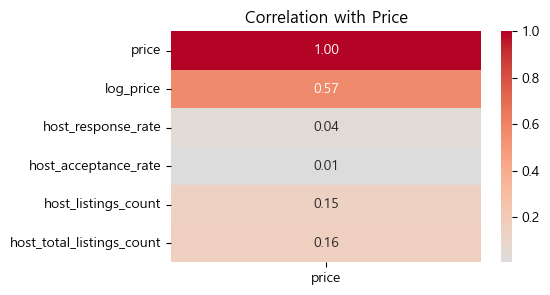

In [7]:
plt.figure(figsize=(5,3))

sns.heatmap(
    df[price_host_cols].corr()[['price']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)

plt.title("Correlation with Price")
plt.show()

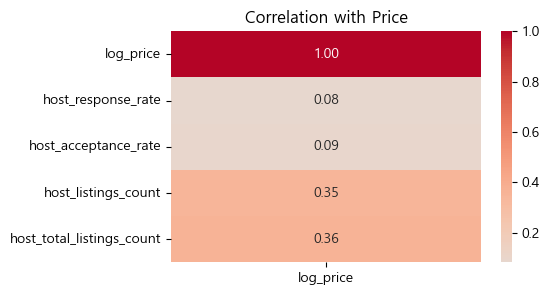

In [8]:
plt.figure(figsize=(5,3))

sns.heatmap(
    df[price_host_cols].corr()[1:][['log_price']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)

plt.title("Correlation with Price")
plt.show()

In [9]:
#슈퍼호스트 여부와 가격
superhost_price_df = df.groupby('host_is_superhost').agg(
    price_mean = ('price','mean'),
    superhost_count = ('id','count'),
     occupied_date = ('estimated_occupancy_l365d','mean')
)
superhost_price_df.round(2)

,price_mean,superhost_count,occupied_date
host_is_superhost,,,
False,227.76,15799,43.44
True,178.78,6135,141.79


count    17915.000000
mean         0.930423
std          0.192891
min          0.000000
25%          0.990000
50%          1.000000
75%          1.000000
max          1.000000
Name: host_response_rate, dtype: float64

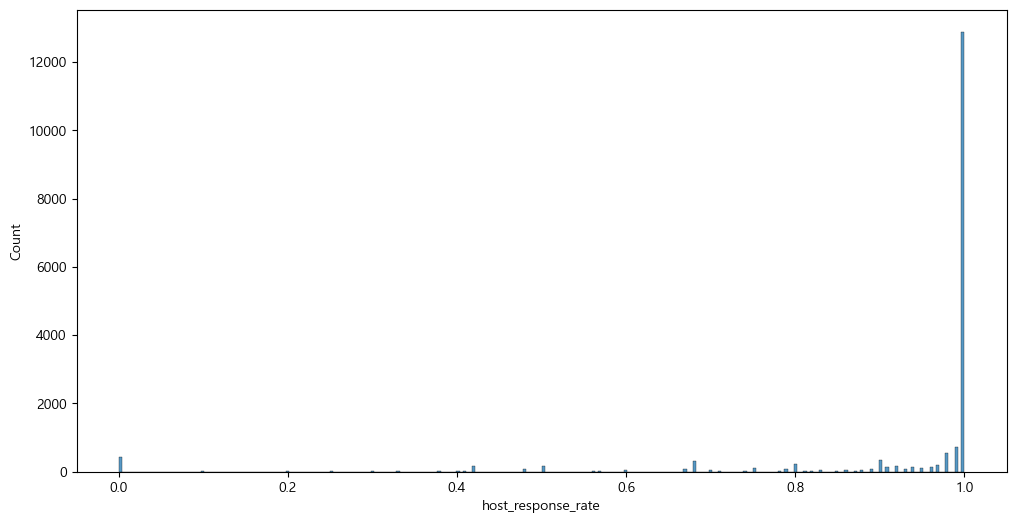

In [10]:
sns.histplot(df['host_response_rate'])
df['host_response_rate'].describe()

<Axes: xlabel='host_acceptance_rate', ylabel='Count'>

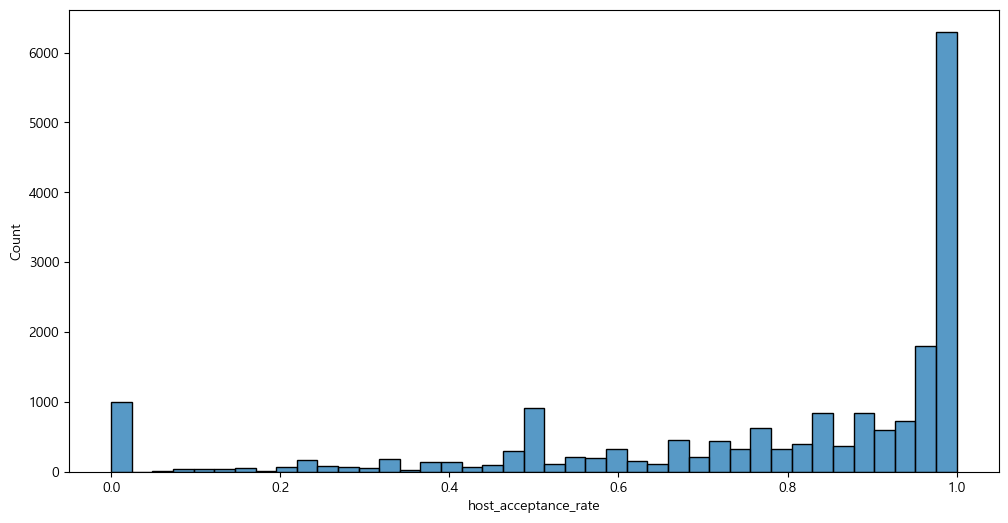

In [11]:
df['host_acceptance_rate'].describe()
sns.histplot(df['host_acceptance_rate'])

# neighbourhood_group_cleansed - 가격 관련

In [12]:
group_price_df = df.groupby('neighbourhood_group_cleansed').agg(
    price_mean = ('price','mean'),
    price_median = ('price','median'),
    group_count = ('id','count'),
     occupied_days = ('estimated_occupancy_l365d','mean')
)
group_price_df.round(2)

,price_mean,price_median,group_count,occupied_days
neighbourhood_group_cleansed,,,,
Bronx,121.81,90.0,912,62.17
Brooklyn,169.65,124.0,7455,79.22
Manhattan,286.34,189.0,10205,64.61
Queens,126.24,96.0,3420,78.06
Staten Island,128.34,99.5,316,72.23


In [13]:
#가격과 그룹별
display(group_price_df['price_mean'])

neighbourhood_group_cleansed
Bronx            121.807018
Brooklyn         169.646680
Manhattan        286.343557
Queens           126.239474
Staten Island    128.344937
Name: price_mean, dtype: float64

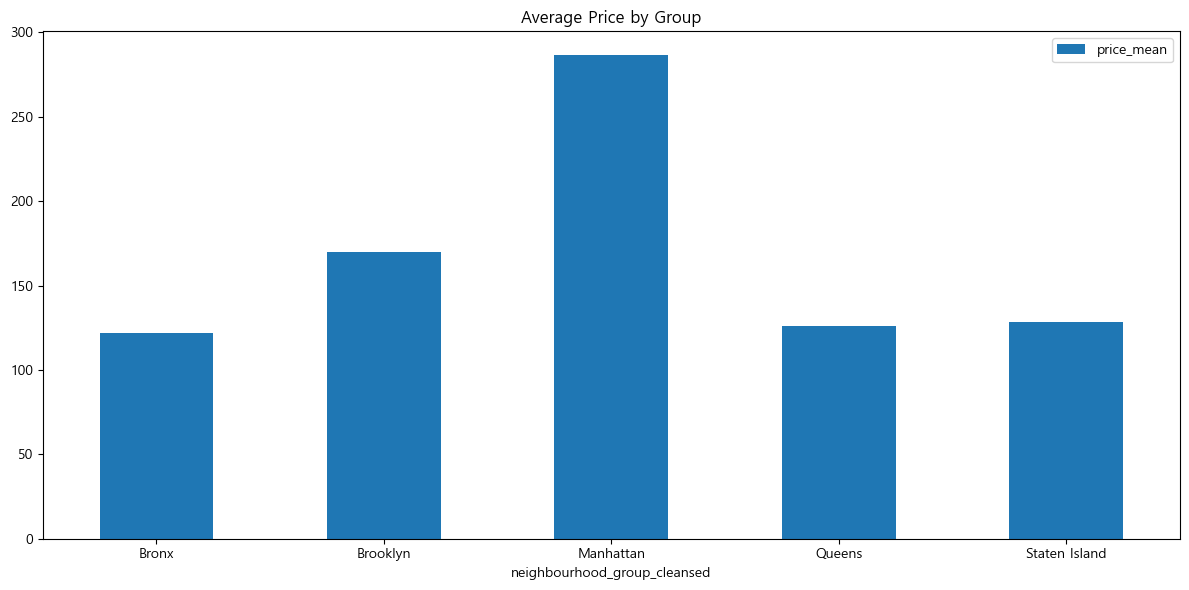

In [14]:
#도시 별 가격 정보
group_price_df['price_mean'].plot(kind='bar', rot = 0,title='Average Price by Group')

plt.tight_layout()
plt.legend()
plt.show()

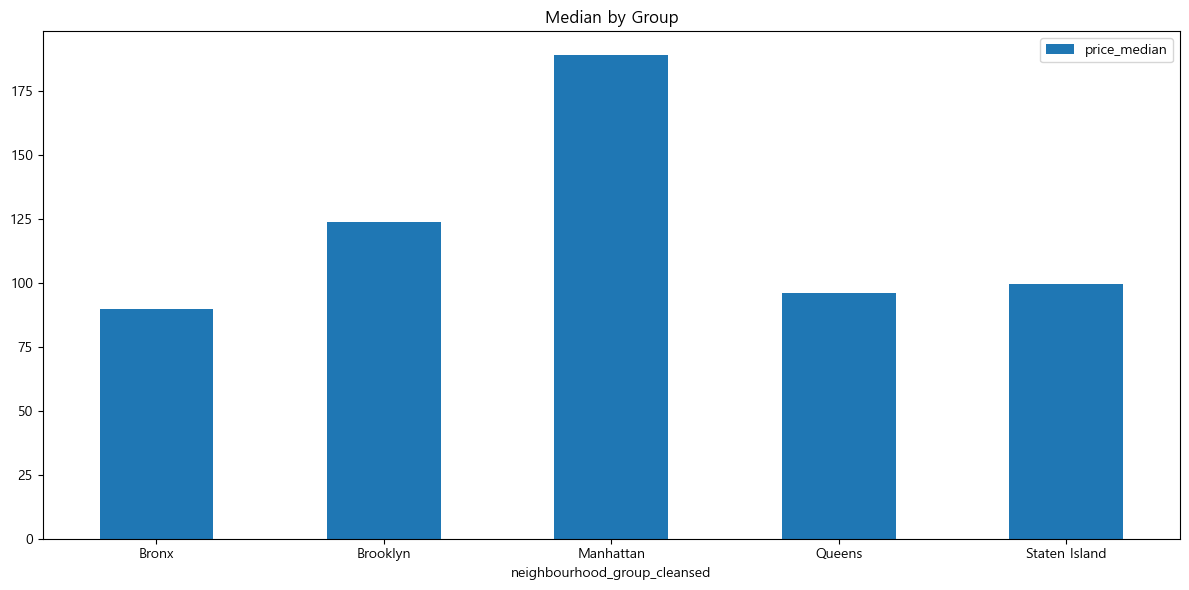

In [15]:
group_price_df['price_median'].plot(kind='bar', rot = 0,title='Median by Group')
plt.tight_layout()
plt.legend()
plt.show()

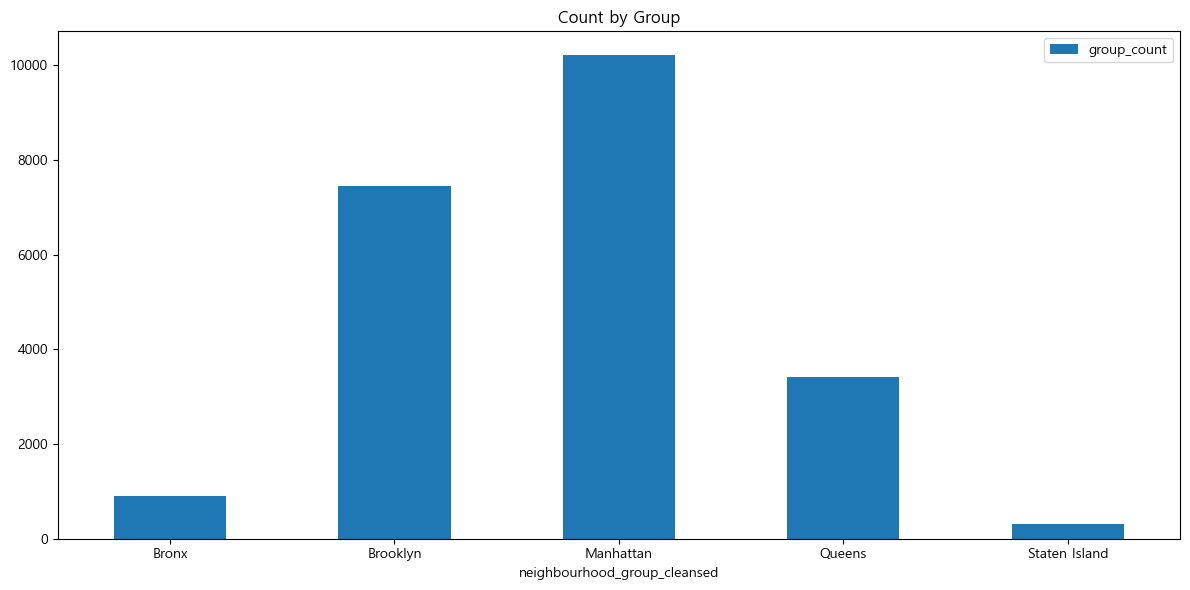

In [16]:
group_price_df['group_count'].plot(kind='bar', rot = 0,title='Count by Group')
plt.tight_layout()
plt.legend()
plt.show()


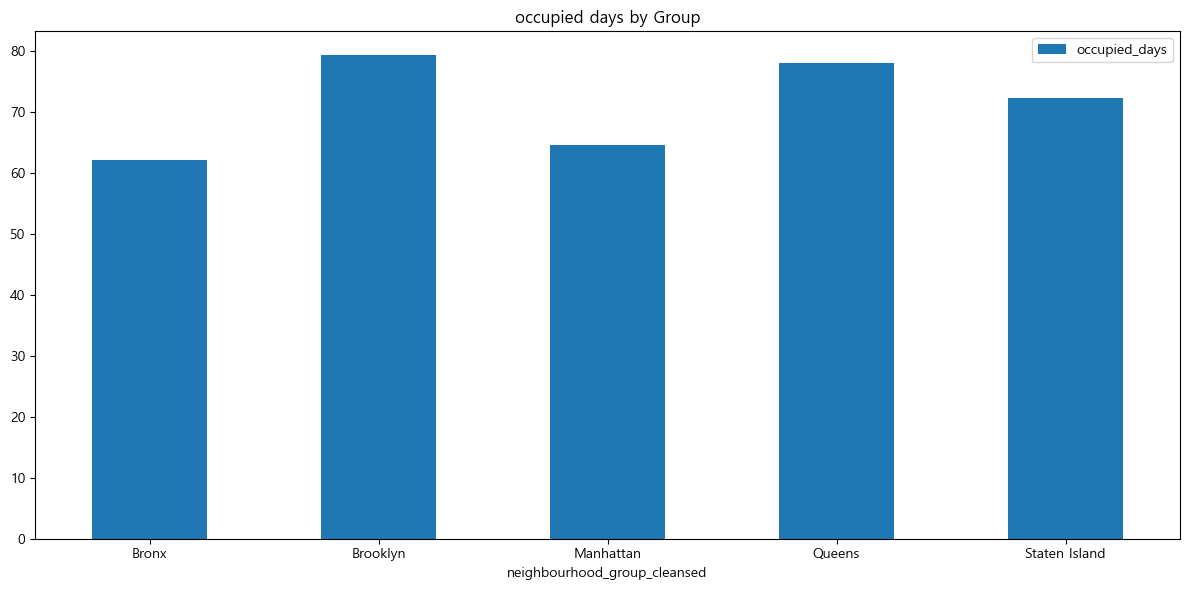

In [17]:
group_price_df['occupied_days'].plot(kind='bar', rot = 0,title='occupied days by Group')
plt.tight_layout()
plt.legend()
plt.show()


<Axes: title={'center': 'log_price'}, xlabel='neighbourhood_group_cleansed'>

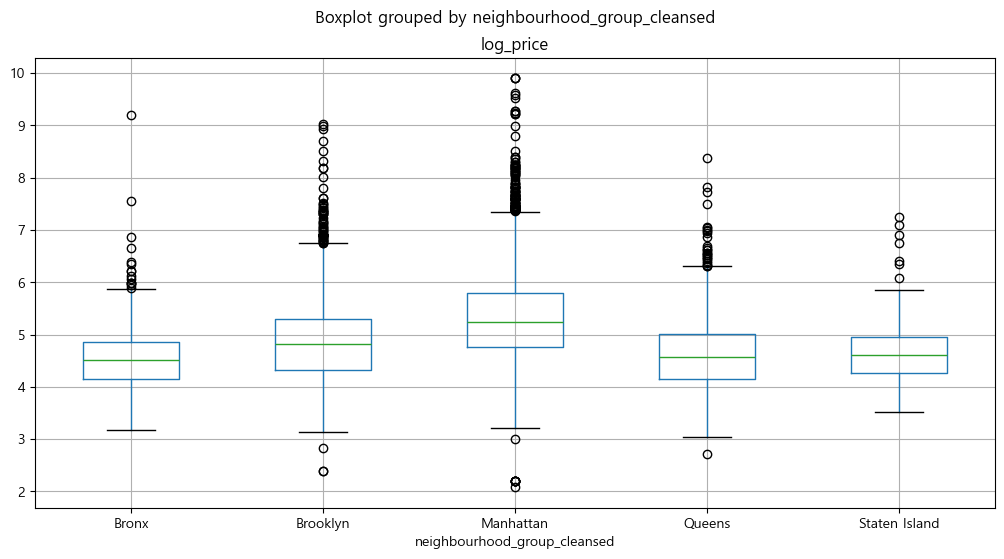

In [18]:
df.boxplot(column='log_price',by='neighbourhood_group_cleansed')

Brooklyn shapiro (p-value): 6.849273285663981e-97
Manhattan shapiro (p-value): 1.1739086546093911e-108
Queens shapiro (p-value): 7.168164116467101e-73
Bronx shapiro (p-value): 4.3287071407295247e-54
Staten Island shapiro (p-value): 2.5394791484847276e-29


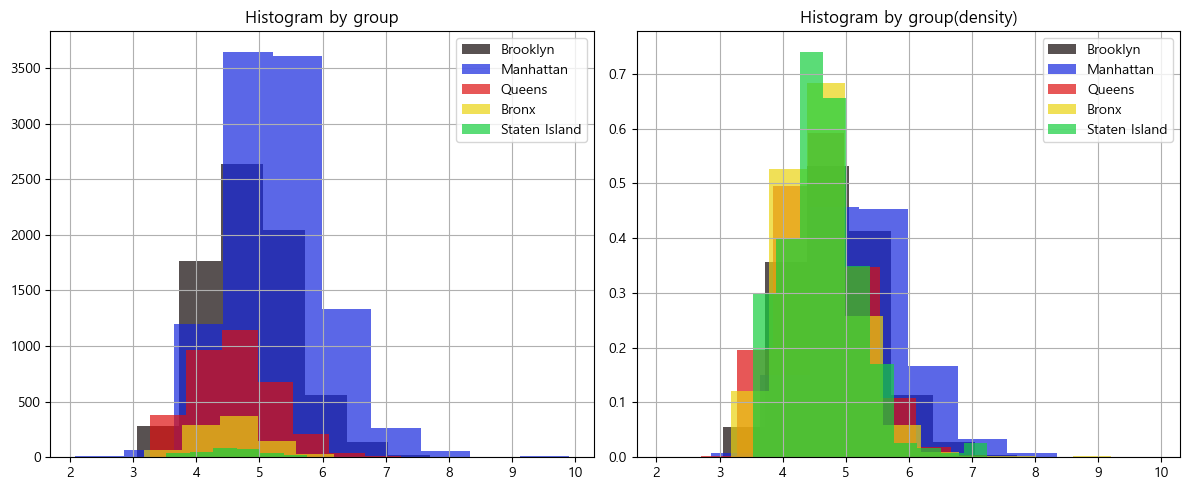

In [19]:
from scipy import stats
import numpy as np
group_cols = df['neighbourhood_group_cleansed'].unique()
group_cols
color_cols = ["#110707","#1626DE","#DE1010","#EAD410","#16CE3E"]

for i in group_cols:
    print(f'{i} shapiro (p-value): {stats.shapiro(df[df['neighbourhood_group_cleansed']==i]['price'])[1]}')
    
    
fig, ax = plt.subplots(1,2,figsize=(12,5))

for idx, g in enumerate(group_cols):
    group_price = df[df["neighbourhood_group_cleansed"] == g]["log_price"]
    group_price.hist(color=color_cols[idx],ax=ax[0], label=g, alpha = 0.7)
    
    
for idx, g in enumerate(group_cols):
    group_price = df[df["neighbourhood_group_cleansed"] == g]["log_price"]
    group_price.hist(color=color_cols[idx],ax=ax[1], label=g, alpha = 0.7, density=True)

ax[0].set_title('Histogram by group')
ax[1].set_title('Histogram by group(density)')

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()
#y축을 비율로



In [20]:
grouped_log_price = df.groupby('neighbourhood_group_cleansed')['log_price']

In [21]:
for g, data in grouped_log_price:
    print(g)
    print(data.head(1))

Bronx
31    4.110874
Name: log_price, dtype: float64
Brooklyn
0    5.303305
Name: log_price, dtype: float64
Manhattan
1    4.418841
Name: log_price, dtype: float64
Queens
30    6.282267
Name: log_price, dtype: float64
Staten Island
117    4.762174
Name: log_price, dtype: float64


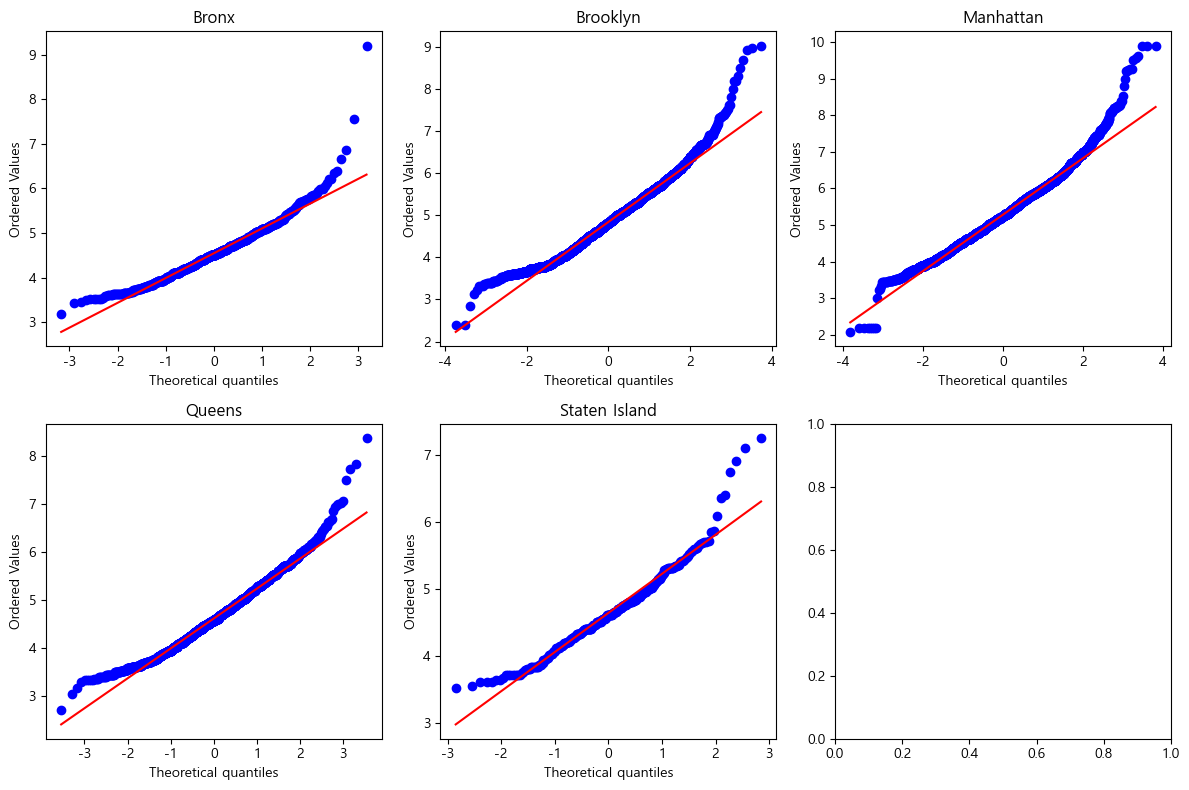

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (g, data) in zip(axes, grouped_log_price):
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(g)



plt.tight_layout()
plt.show()

# 도시별 log(price) ANOVA

In [23]:
from scipy import stats

grouped_log_price = df.groupby('neighbourhood_group_cleansed')['log_price']

for g, group in grouped_log_price:
    sw_stat, sw_p = stats.shapiro(group)
    print(f"{g} p-value (shapiro) : {sw_p}")


Bronx p-value (shapiro) : 1.7362378737574658e-17
Brooklyn p-value (shapiro) : 1.8243672971182663e-30
Manhattan p-value (shapiro) : 1.0355212477851364e-31
Queens p-value (shapiro) : 1.0049467164930776e-19
Staten Island p-value (shapiro) : 1.4533059902511121e-08


In [24]:
lev_stat, lev_p = stats.levene(*[group for _, group in grouped_log_price])

print(f'Levene 등분산 검정 결과: {lev_p}')

Levene 등분산 검정 결과: 1.1292585496143832e-56


In [25]:
import pingouin as pg
group_anova = pg.welch_anova(dv='log_price',
    between='neighbourhood_group_cleansed',
    data=df)
display(group_anova)

print(f'p-value: {group_anova['p_unc'].values[0]}')
print(f'효과크기: {group_anova['np2'].values[0]:.4f} (0.01 / 0.06 / 0.14)')

,Source,ddof1,ddof2,F,p_unc,np2
0,neighbourhood_group_cleansed,4,1862.425742,883.611959,0.0,0.129297


p-value: 0.0
효과크기: 0.1293 (0.01 / 0.06 / 0.14)


In [26]:
gh = pg.pairwise_gameshowell(dv='log_price', between='neighbourhood_group_cleansed',
                             data=df)

# Games-Howell 사후검정

gh[['A','B','diff','pval','hedges']]

,A,B,diff,pval,hedges
0,Bronx,Brooklyn,-0.294928,3.813616e-13,-0.425861
1,Bronx,Manhattan,-0.735743,0.000000e+00,-0.964967
2,Bronx,Queens,-0.071314,9.301790e-03,-0.115632
3,Bronx,Staten Island,-0.091713,1.198218e-01,-0.158978
4,Brooklyn,Manhattan,-0.440815,0.000000e+00,-0.589313
5,Brooklyn,Queens,0.223614,6.984413e-13,0.327608
6,Brooklyn,Staten Island,0.203215,8.182512e-08,0.289545
7,Manhattan,Queens,0.664429,0.000000e+00,0.894571
8,Manhattan,Staten Island,0.644030,4.407585e-14,0.833754
9,Queens,Staten Island,-0.020399,9.778076e-01,-0.032603


# room type 별 price

In [27]:
room_price_df = df.groupby('room_type').agg(
    price_mean = ('price','mean'),
    price_median = ('price', 'median'),
    room_count = ('id','count'),
     occupied_days = ('estimated_occupancy_l365d','mean')
)

room_price_df

,price_mean,price_median,room_count,occupied_days
room_type,,,,
Entire home/apt,265.344757,190.0,12664,72.955701
Hotel room,527.634409,403.0,372,12.591398
Private room,130.763009,81.0,9186,71.979643
Shared room,144.662791,79.0,86,76.988372


In [28]:
#방 타입 별 평균 가격
display(room_price_df['price_mean'])

room_type
Entire home/apt    265.344757
Hotel room         527.634409
Private room       130.763009
Shared room        144.662791
Name: price_mean, dtype: float64

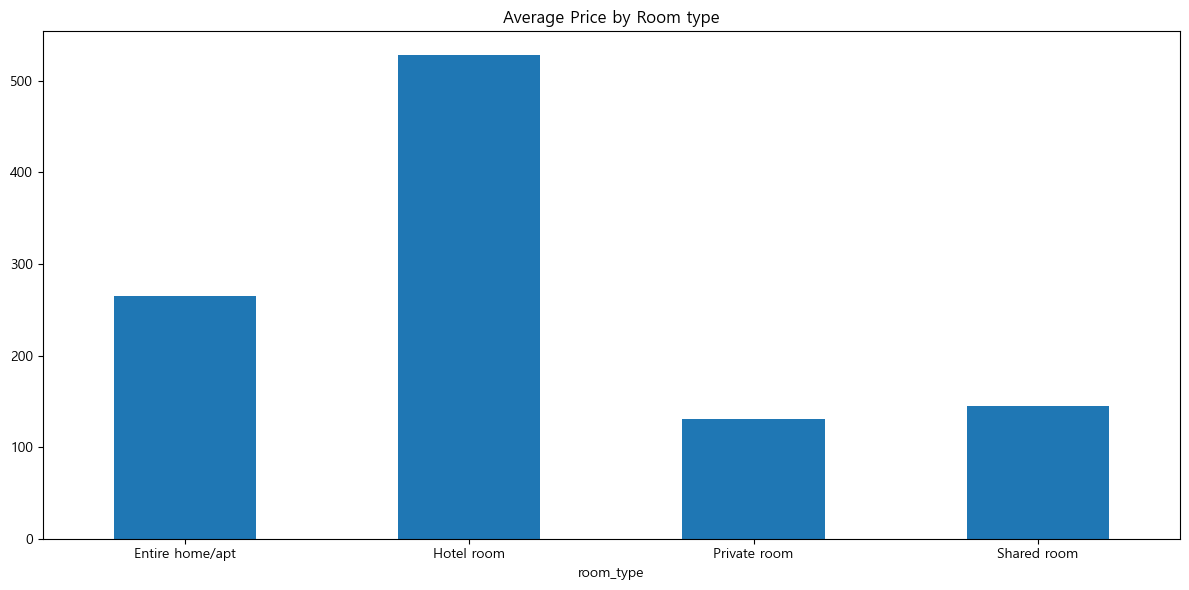

In [29]:
room_price_df['price_mean'].plot(kind='bar',rot = 0, title ='Average Price by Room type')
plt.tight_layout()

In [30]:
#방 타입별 수

display(room_price_df['room_count'])

room_type
Entire home/apt    12664
Hotel room           372
Private room        9186
Shared room           86
Name: room_count, dtype: int64

<Axes: title={'center': 'Median by Room type'}, xlabel='room_type'>

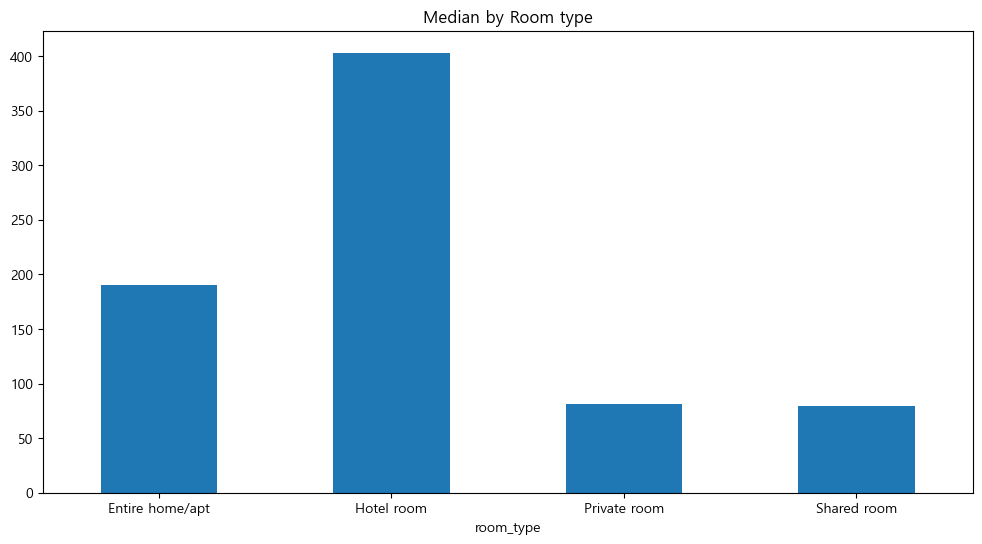

In [31]:
room_price_df['price_median'].plot(kind='bar', rot = 0, title = 'Median by Room type')

<Axes: title={'center': 'Count by Room type'}, xlabel='room_type'>

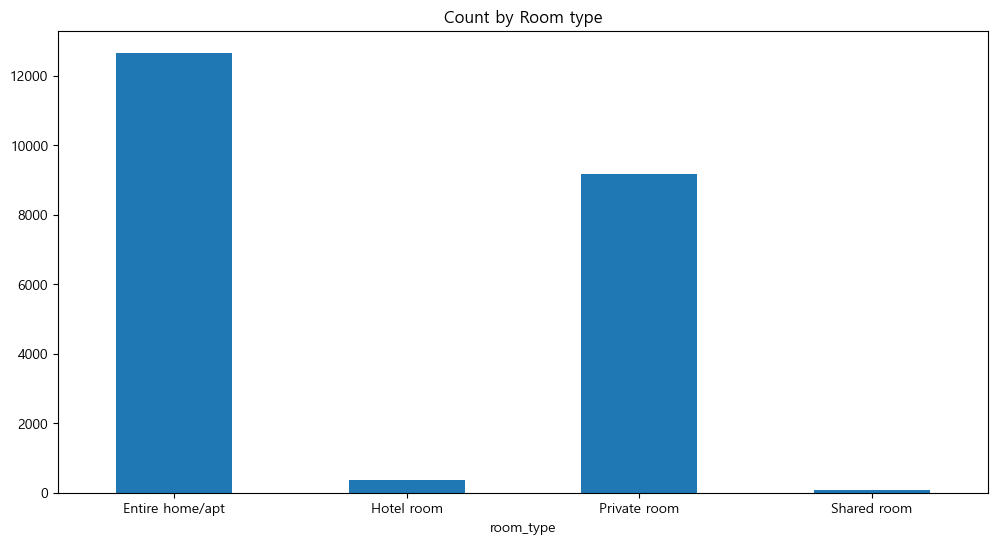

In [32]:
room_price_df['room_count'].plot(kind='bar', rot = 0, title = 'Count by Room type')

<Axes: title={'center': 'occupied days by Room type'}, xlabel='room_type'>

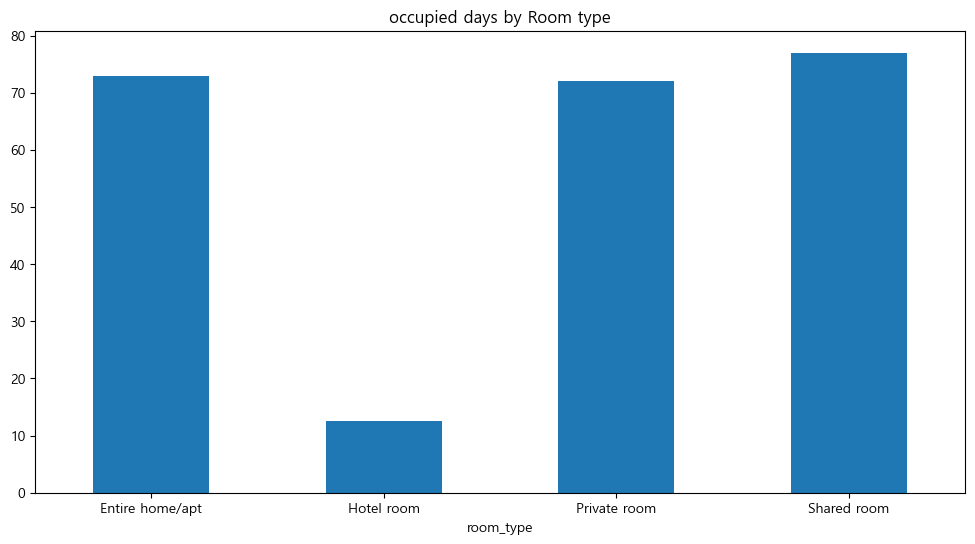

In [33]:
room_price_df['occupied_days'].plot(kind='bar', rot = 0, title = 'occupied days by Room type')

Brooklyn shapiro (p-value): nan
Manhattan shapiro (p-value): nan
Queens shapiro (p-value): nan
Bronx shapiro (p-value): nan
Staten Island shapiro (p-value): nan


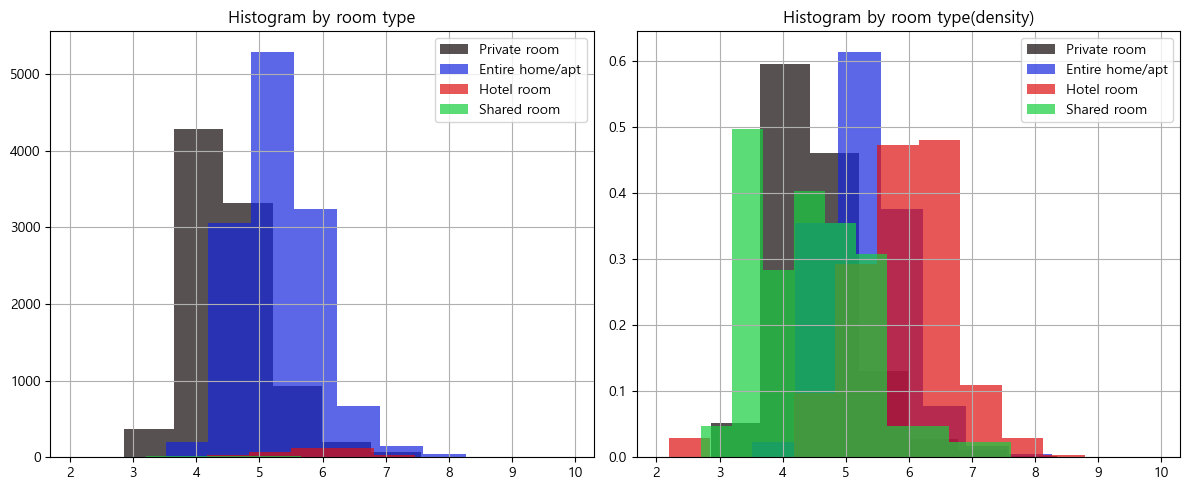

In [34]:
room_cols = df['room_type'].unique()
room_cols
color_cols = ["#110707","#1626DE","#DE1010","#16CE3E"]

for i in group_cols:
    print(f'{i} shapiro (p-value): {stats.shapiro(df[df['room_type']==i]['price'])[1]}')
    
    
fig, ax = plt.subplots(1,2,figsize=(12,5))

for idx, g in enumerate(room_cols):
    room_price = df[df["room_type"] == g]["log_price"]
    room_price.hist(color=color_cols[idx],ax=ax[0], label=g, alpha = 0.7)

for idx, g in enumerate(room_cols):
    room_price = df[df["room_type"] == g]["log_price"]
    room_price.hist(color=color_cols[idx],ax=ax[1], label=g, alpha = 0.7, density = True)

ax[0].set_title('Histogram by room type')
ax[1].set_title('Histogram by room type(density)')
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

<Axes: title={'center': 'log_price'}, xlabel='neighbourhood_group_cleansed'>

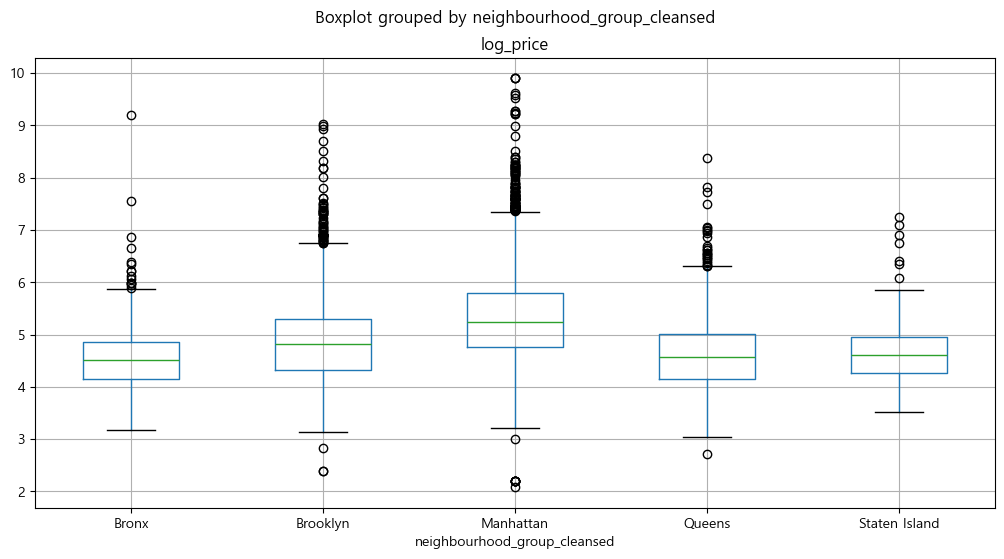

In [35]:
df.boxplot(column='log_price',by='neighbourhood_group_cleansed')

# Place to Stay 항목과 가격 관 상관관계 찍어보기

In [36]:
place_num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds']

place_num_price_cols = ['price','log_price'] + place_num_cols

df[place_num_price_cols].corr()['price']

price           1.000000
log_price       0.570605
accommodates    0.283324
bathrooms       0.217298
bedrooms        0.177070
beds            0.197385
Name: price, dtype: float64

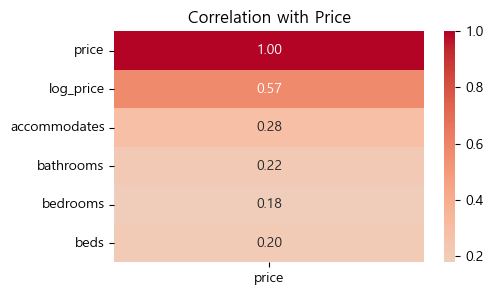

In [37]:
plt.figure(figsize=(5,3))

sns.heatmap(
    df[place_num_price_cols].corr()[['price']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)

plt.title("Correlation with Price")
plt.show()

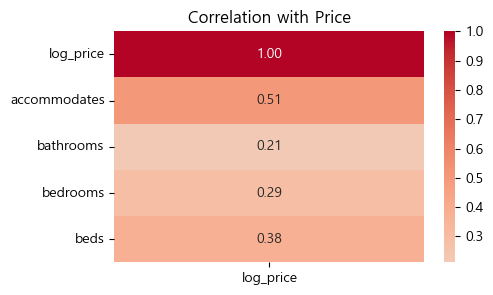

In [38]:
plt.figure(figsize=(5,3))

sns.heatmap(
    df[place_num_price_cols].corr()[1:][['log_price']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0
)

plt.title("Correlation with Price")
plt.show()

In [39]:
review_score_cols = ['number_of_reviews','reviews_per_month','review_scores_rating',
                     'review_scores_cleanliness','review_scores_communication',
                     'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly',
                     'review_scores_accuracy', 'review_scores_cleanliness','review_scores_checkin',
                     'review_scores_communication', 'review_scores_location', 'review_scores_value']

price_review_score_cols = ['price'] + review_score_cols

df[price_review_score_cols].corr()['price']

price                          1.000000
number_of_reviews             -0.051742
reviews_per_month             -0.011764
review_scores_rating           0.043957
review_scores_cleanliness      0.055828
review_scores_communication    0.023769
number_of_reviews_ltm         -0.020382
number_of_reviews_l30d        -0.013426
number_of_reviews_ly          -0.020200
review_scores_accuracy         0.034710
review_scores_cleanliness      0.055828
review_scores_checkin          0.022294
review_scores_communication    0.023769
review_scores_location         0.085849
review_scores_value            0.012483
Name: price, dtype: float64

In [40]:
df['estimated_occupancy_l365d'].describe()

count    22308.000000
mean        71.562713
std         96.622429
min          0.000000
25%          0.000000
50%          0.000000
75%        120.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64

In [41]:
bookable_df = df.groupby('instant_bookable').agg(
    price_mean = ('price','mean'),
    price_median = ('price','median'),
    cnt = ('id','count')
)
bookable_df.round(2)

,price_mean,price_median,cnt
instant_bookable,,,
False,186.68,126.0,16618
True,293.15,200.0,5690


In [42]:
df['property_type'].describe()

count                  22308
unique                    57
top       Entire rental unit
freq                    9648
Name: property_type, dtype: object

# Group과 review

In [43]:
group_review_df = df.groupby('neighbourhood_group_cleansed')[review_score_cols].mean()

group_review_df

,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_communication,number_of_reviews_ltm,number_of_reviews_l30d,number_of_reviews_ly,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
neighbourhood_group_cleansed,,,,,,,,,,,,,,
Bronx,29.246711,0.897092,4.713092,4.694582,4.830809,4.039474,0.166667,3.963816,4.752979,4.694582,4.813078,4.830809,4.573206,4.663206
Brooklyn,42.576123,1.162780,4.776353,4.728917,4.859399,6.465325,0.297653,6.269618,4.805099,4.728917,4.871593,4.859399,4.706864,4.686410
Manhattan,25.894072,1.105239,4.664970,4.625789,4.755717,5.681431,0.352376,5.438707,4.693743,4.625789,4.787413,4.755717,4.774043,4.509217
Queens,42.660234,1.355492,4.750089,4.733797,4.838993,7.515205,0.329240,7.238012,4.775444,4.733797,4.850718,4.838993,4.713602,4.679334
Staten Island,38.367089,1.092817,4.797103,4.788929,4.890595,4.246835,0.208861,4.199367,4.817500,4.788929,4.876667,4.890595,4.737698,4.730635


# reservation과 가격

In [44]:
reservation_num_cols = ['minimum_nights','maximum_nights','minimum_minimum_nights','maximum_minimum_nights',
                        'minimum_maximum_nights','maximum_maximum_nights','minimum_nights_avg_ntm','maximum_nights_avg_ntm',
                        'availability_30','availability_60','availability_90','availability_365','availability_eoy',
                        'estimated_occupancy_l365d','estimated_revenue_l365d','calculated_host_listings_count','calculated_host_listings_count_entire_homes',
                        'calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms']

reservation_num_cols_price = ['price','log_price']+reservation_num_cols

df[reservation_num_cols_price].corr()['log_price'][1:][lambda x: abs(x)>=0.1]

log_price                                       1.000000
maximum_nights                                  0.119132
maximum_minimum_nights                          0.175244
estimated_revenue_l365d                         0.229946
calculated_host_listings_count                  0.261145
calculated_host_listings_count_entire_homes     0.305299
calculated_host_listings_count_private_rooms   -0.226294
Name: log_price, dtype: float64

# property_type 관련

In [45]:
df['property_type']

0        Private room in rental unit
1              Private room in condo
2               Private room in home
3                        Entire home
4        Private room in rental unit
                    ...             
22303    Private room in rental unit
22304    Private room in rental unit
22305             Entire rental unit
22306             Entire rental unit
22307    Private room in rental unit
Name: property_type, Length: 22308, dtype: str

In [46]:
#운영형태와 대여 규모에 따라?

def group_property(x):
    x = str(x).lower()
    
    if any(word in x for word in ['apartment', 'condo', 'loft','unit']):
        return 'Apartment'
    elif any(word in x for word in ['hotel']):
        return 'Commercial'
    elif any(word in x for word in ['home', 'villa','cottage','house']):
        return 'House'
    else:
        return 'Other'

df['property_grouped'] = df['property_type'].apply(group_property)

In [47]:
df['property_grouped'].value_counts()

property_grouped
Apartment     16503
House          4042
Commercial     1083
Other           680
Name: count, dtype: int64

<Axes: title={'center': 'log_price'}, xlabel='property_grouped'>

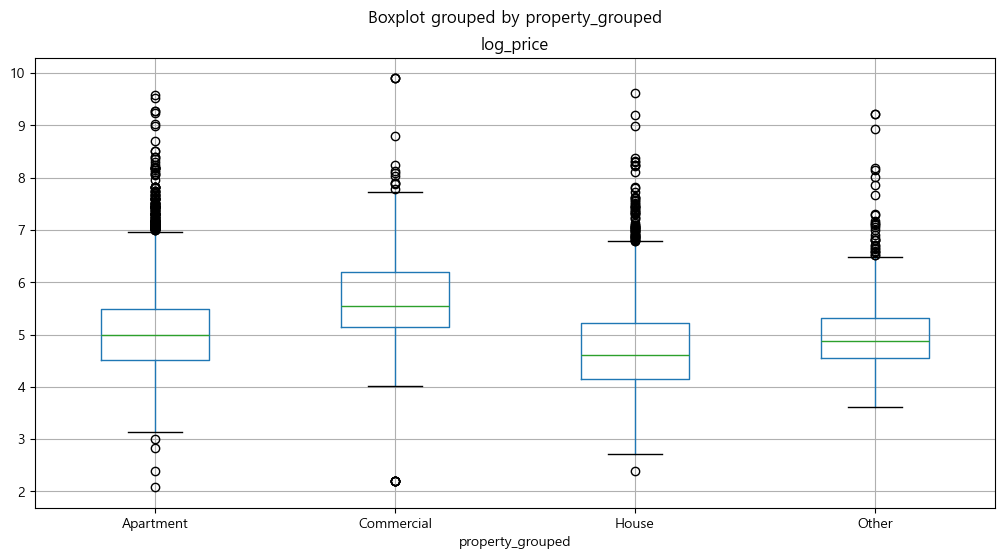

In [48]:
df.boxplot(column='log_price',by = 'property_grouped')

In [49]:
property_group = df.groupby(['neighbourhood_group_cleansed','property_grouped']).agg(
    price_mean = ('price','mean'),
    price_median = ('price','median'),
    cnt = ('id','count')
)

property_group.round(2)

price_mean  price_median   cnt
neighbourhood_group_cleansed property_grouped                                
Bronx                        Apartment             107.06          92.0   517
                             Commercial            170.00         170.0     4
                             House                 141.94          87.0   347
                             Other                 132.00         104.0    44
Brooklyn                     Apartment             156.63         120.0  5489
                             Commercial            367.50         207.5    62
                             House                 198.75         126.0  1596
                             Other                 211.02         148.0   308
Manhattan                    Apartment             255.88         180.0  8772
                             Commercial            484.54         272.0   976
                             House                 423.07         200.0   317
                             Other                 503.86         160.0   140
Queens                       Apartment             128.22         105.0  1612
                             Commercial            185.59         194.0    41
                             House                 122.26          86.0  1599
                             Other                 130.61         113.0   168
Staten Island                Apartment             106.30          95.0   113
                             House                 144.63         100.0   183
                             Other                 103.85         104.0    20

<Axes: title={'center': 'log_price'}, xlabel='property_grouped'>

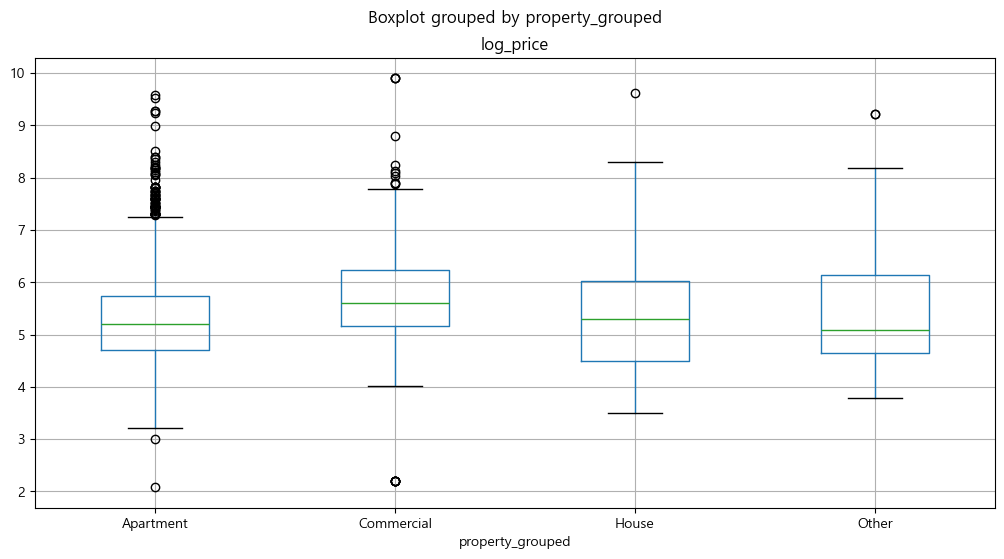

In [50]:
df[df['neighbourhood_group_cleansed']=='Manhattan'].boxplot(column = 'log_price',
                                                            by='property_grouped')

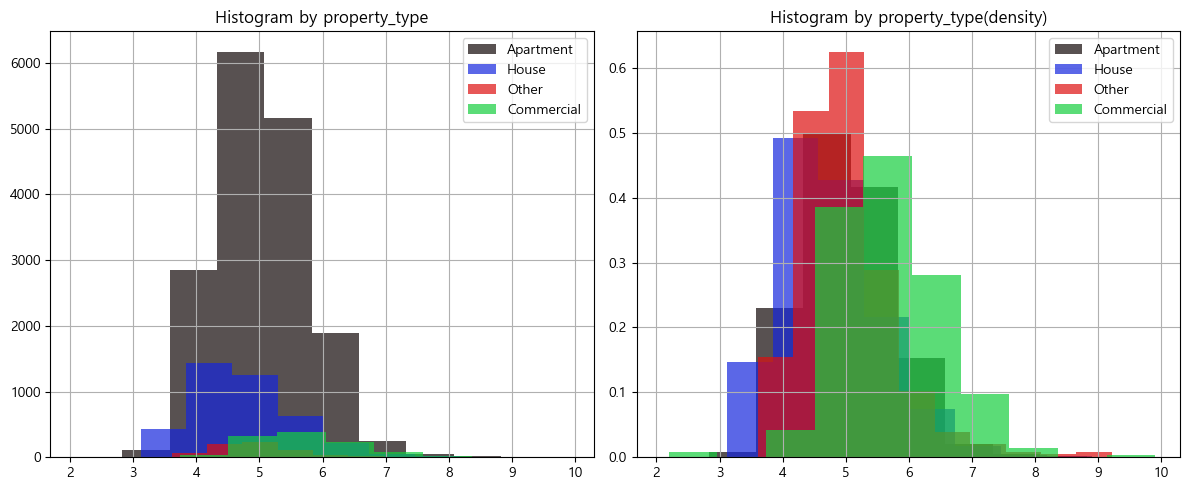

In [51]:
room_cols = df['property_grouped'].unique()
room_cols
color_cols = ["#110707","#1626DE","#DE1010","#16CE3E"]
    
    
fig, ax = plt.subplots(1,2,figsize=(12,5))

for idx, g in enumerate(room_cols):
    room_price = df[df["property_grouped"] == g]["log_price"]
    room_price.hist(color=color_cols[idx],ax=ax[0], label=g, alpha = 0.7)

for idx, g in enumerate(room_cols):
    room_price = df[df["property_grouped"] == g]["log_price"]
    room_price.hist(color=color_cols[idx],ax=ax[1], label=g, alpha = 0.7, density = True)

ax[0].set_title('Histogram by property_type')
ax[1].set_title('Histogram by property_type(density)')
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

In [52]:
df[df['property_grouped']=='Other']['property_type'].value_counts()

property_type
Entire guest suite                    272
Private room in guest suite           114
Entire place                           61
Private room in bed and breakfast      60
Private room in casa particular        41
Private room                           28
Private room in resort                 28
Private room in hostel                 26
Entire bungalow                        13
Private room in bungalow                9
Camper/RV                               8
Boat                                    5
Tower                                   3
Private room in religious building      2
Casa particular                         2
Barn                                    1
Private room in camper/rv               1
Private room in kezhan                  1
Shared room in guest suite              1
Private room in ranch                   1
Shared room in casa particular          1
Private room in tower                   1
Private room in dome                    1
Name: count, dtype: 

# roomtype과 가격

In [53]:
grouped_roomtype_log_price = df.groupby('room_type')['log_price']
grouped_roomtype_log_price

In [54]:
for g, group in grouped_roomtype_log_price:
    sw_stat, sw_p = stats.shapiro(group)
    print(f"{g} p-value (shapiro) : {sw_p}")
    
display(df.groupby('room_type')['log_price'].agg(['skew', 'kurt']))

Entire home/apt p-value (shapiro) : 5.809698541420056e-48
Hotel room p-value (shapiro) : 2.292323529060344e-13
Private room p-value (shapiro) : 6.355975267902711e-56
Shared room p-value (shapiro) : 0.0015876833675235022


,skew,kurt
room_type,,
Entire home/apt,0.875083,2.201221
Hotel room,-1.133361,4.164304
Private room,1.366606,4.085343
Shared room,0.850541,1.123505


In [55]:
lev_stat, lev_p = stats.levene(*[group for _, group in grouped_roomtype_log_price])

print(f'Levene 등분산 검정 결과: {lev_p}')

Levene 등분산 검정 결과: 5.0356204451789e-15


In [56]:
group_anova = pg.welch_anova(dv='log_price',
    between='neighbourhood_group_cleansed',
    data=df)
display(group_anova)

print(f'p-value: {group_anova['p_unc'].values[0]}')
print(f'효과크기: {group_anova['np2'].values[0]:.4f} (0.01 / 0.06 / 0.14)')

,Source,ddof1,ddof2,F,p_unc,np2
0,neighbourhood_group_cleansed,4,1862.425742,883.611959,0.0,0.129297


p-value: 0.0
효과크기: 0.1293 (0.01 / 0.06 / 0.14)


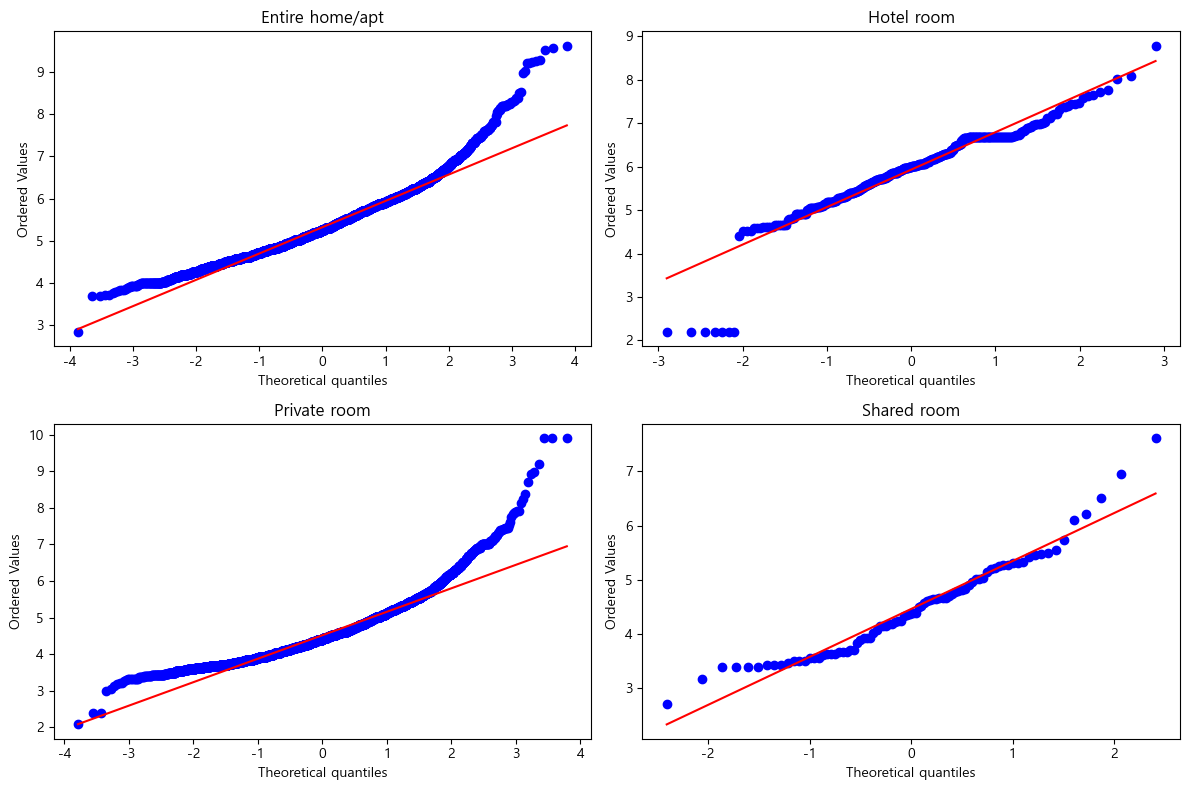

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (g, data) in zip(axes, grouped_roomtype_log_price):
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(g)



plt.tight_layout()
plt.show()

In [58]:
#Krustal_Wallis 검정

kru_stat, kru_p = stats.kruskal(*[group for _, group in grouped_roomtype_log_price])
print(f'stats: {kru_stat:.2f}, pvalue: {kru_p:.2f}')

stats: 7268.70, pvalue: 0.00


In [59]:
import scikit_posthocs as sp


# Dunn 검정 수행
dunn_result = sp.posthoc_dunn(df, val_col='log_price', group_col='room_type')

print(dunn_result)

                 Entire home/apt     Hotel room   Private room   Shared room
Entire home/apt     1.000000e+00   8.811354e-33   0.000000e+00  8.678012e-25
Hotel room          8.811354e-33   1.000000e+00  7.667248e-242  6.892584e-48
Private room        0.000000e+00  7.667248e-242   1.000000e+00  8.764756e-01
Shared room         8.678012e-25   6.892584e-48   8.764756e-01  1.000000e+00


<Axes: title={'center': 'log_price'}, xlabel='room_type'>

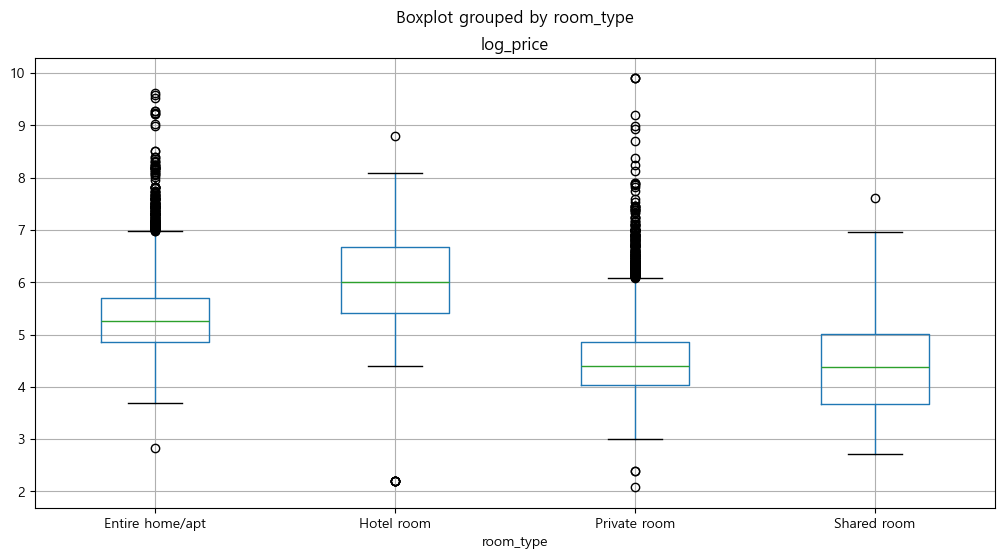

In [60]:
df.boxplot(column='log_price',by='room_type')

In [61]:
expensive_group = df[ (df['property_grouped']=='Commercial') &
                     (df['neighbourhood_group_cleansed']=='Manhattan')] 

expensive_group['host_is_superhost'].value_counts()

host_is_superhost
False    867
True     109
Name: count, dtype: int64

In [68]:
property_group_host = df.groupby(['neighbourhood_group_cleansed','property_grouped']).agg(
    host_list_all_mean = ('host_listings_count','mean'),
    host_list_all_median = ('host_listings_count','median'),
    host_list_airbnb_mean = ('host_total_listings_count','mean'),
    host_list_airbnb_median = ('host_total_listings_count','median')
)

property_group_host.round(2)

host_list_all_mean  \
neighbourhood_group_cleansed property_grouped                       
Bronx                        Apartment                      34.84   
                             Commercial                      3.00   
                             House                           4.66   
                             Other                           3.32   
Brooklyn                     Apartment                     114.75   
                             Commercial                    750.53   
                             House                           5.69   
                             Other                           2.64   
Manhattan                    Apartment                     814.06   
                             Commercial                    747.99   
                             House                         127.64   
                             Other                          21.47   
Queens                       Apartment                      69.59   
                             Commercial                     26.76   
                             House                          35.29   
                             Other                           2.62   
Staten Island                Apartment                       3.21   
                             House                           2.60   
                             Other                           1.75   

                                               host_list_all_median  \
neighbourhood_group_cleansed property_grouped                         
Bronx                        Apartment                          2.0   
                             Commercial                         3.0   
                             House                              2.0   
                             Other                              1.0   
Brooklyn                     Apartment                          2.0   
                             Commercial                         7.5   
                             House                              2.0   
                             Other                              1.0   
Manhattan                    Apartment                         13.0   
                             Commercial                        20.0   
                             House                              4.0   
                             Other                              9.0   
Queens                       Apartment                          2.0   
                             Commercial                         8.0   
                             House                              3.0   
                             Other                              1.0   
Staten Island                Apartment                          2.0   
                             House                              1.5   
                             Other                              1.0   

                                               host_list_airbnb_mean  \
neighbourhood_group_cleansed property_grouped                          
Bronx                        Apartment                        106.21   
                             Commercial                         4.50   
                             House                              7.68   
                             Other                              4.55   
Brooklyn                     Apartment                        142.94   
                             Commercial                      1504.68   
                             House                              7.69   
                             Other                              3.87   
Manhattan                    Apartment                        928.59   
                             Commercial                      1711.81   
                             House                            140.90   
                             Other                             23.49   
Queens                       Apartment                         88.57   
                         

In [69]:
man_apt = df[ (df['property_grouped']=='Apartment') &
                     (df['neighbourhood_group_cleansed']=='Manhattan')] 

man_co = df[ (df['property_grouped']=='Commercial') &
                     (df['neighbourhood_group_cleansed']=='Manhattan')] 

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

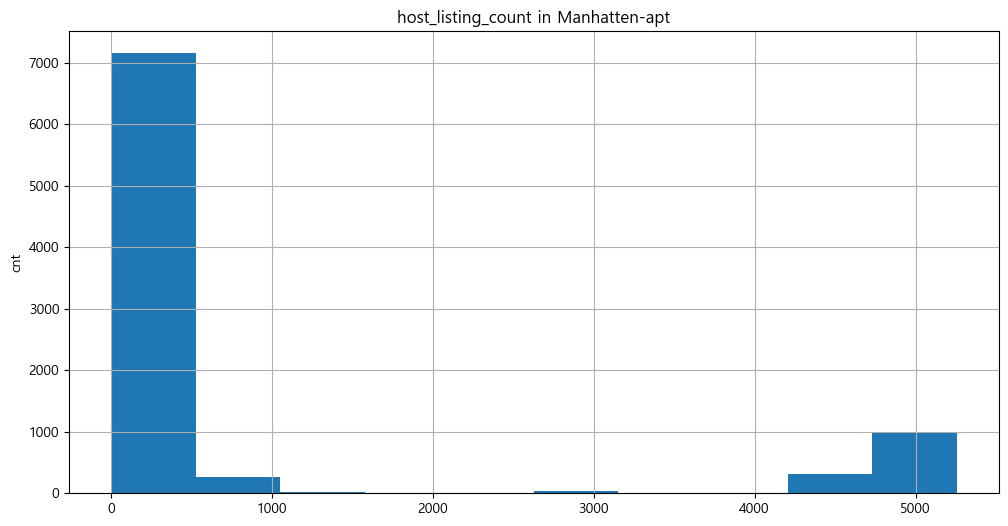

In [77]:
man_apt['host_listings_count'].hist()

plt.title('host_listing_count in Manhatten-apt')
plt.ylabel('cnt')
plt.tight_layout

Text(0.5, 1.0, 'hosting_listing_count in Manhattan-commercial')

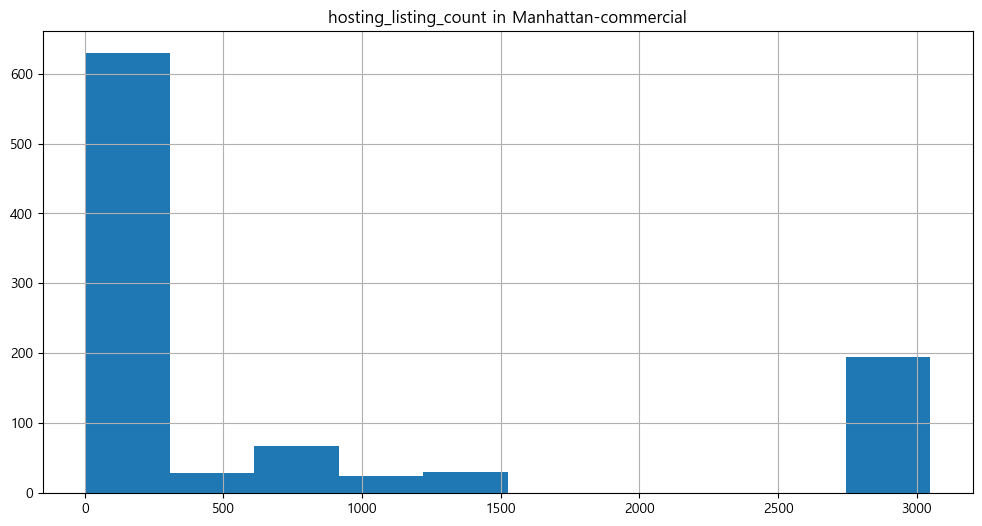

In [78]:
man_co['host_listings_count'].hist()

plt.title('hosting_listing_count in Manhattan-commercial')

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

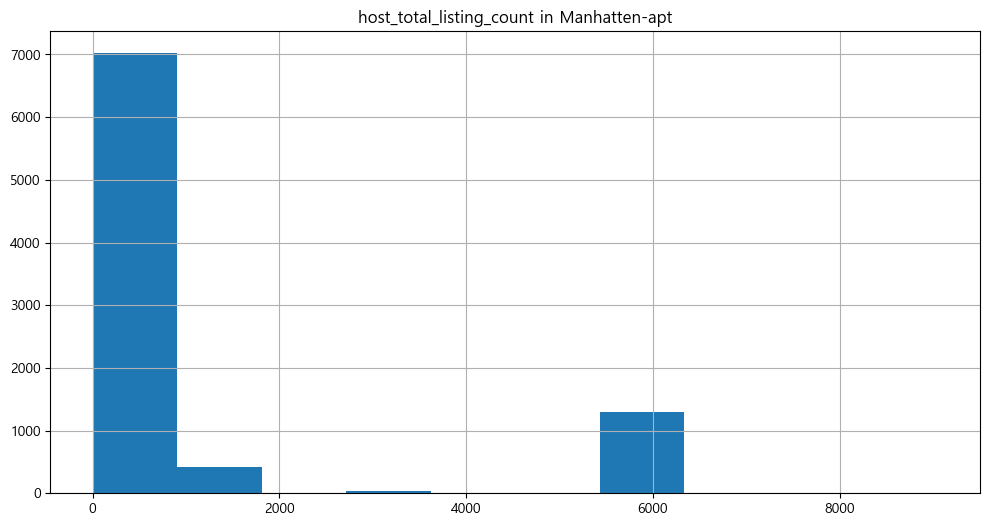

In [79]:
man_apt['host_total_listings_count'].hist()

plt.title('host_total_listing_count in Manhatten-apt')

plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

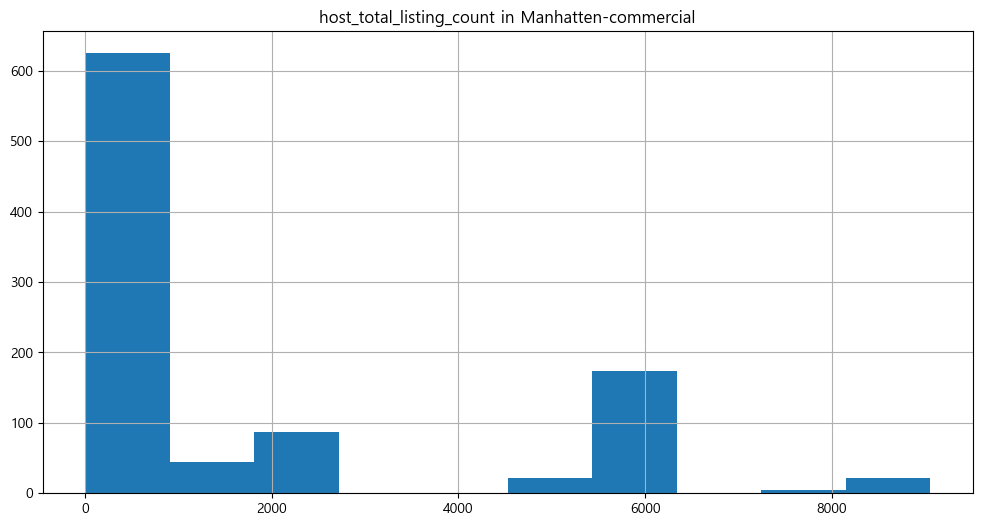

In [80]:
man_co['host_total_listings_count'].hist()

plt.title('host_total_listing_count in Manhatten-commercial')

plt.tight_layout

In [87]:
review_score_property_group = df.groupby(['neighbourhood_group_cleansed','property_grouped'])[['review_scores_rating','review_scores_cleanliness','review_scores_checkin',
                                                'review_scores_communication','review_scores_location','review_scores_value' ]].mean()

review_score_property_group.round(4)

review_scores_rating  \
neighbourhood_group_cleansed property_grouped                         
Bronx                        Apartment                       4.6726   
                             Commercial                      4.2200   
                             House                           4.7639   
                             Other                           4.7821   
Brooklyn                     Apartment                       4.7652   
                             Commercial                      4.6203   
                             House                           4.8068   
                             Other                           4.8080   
Manhattan                    Apartment                       4.6724   
                             Commercial                      4.5453   
                             House                           4.7682   
                             Other                           4.7377   
Queens                       Apartment                       4.7381   
                             Commercial                      4.5527   
                             House                           4.7591   
                             Other                           4.8177   
Staten Island                Apartment                       4.7911   
                             House                           4.8057   
                             Other                           4.7575   

                                               review_scores_cleanliness  \
neighbourhood_group_cleansed property_grouped                              
Bronx                        Apartment                            4.6686   
                             Commercial                           3.9900   
                             House                                4.7211   
                             Other                                4.8121   
Brooklyn                     Apartment                            4.7097   
                             Commercial                           4.7362   
                             House                                4.7718   
                             Other                                4.7937   
Manhattan                    Apartment                            4.6190   
                             Commercial                           4.6433   
                             House                                4.7064   
                             Other                                4.7147   
Queens                       Apartment                            4.7129   
                             Commercial                           4.6524   
                             House                                4.7477   
                             Other                                4.8041   
Staten Island                Apartment                            4.7840   
                             House                                4.7909   
                             Other                                4.8019   

                                               review_scores_checkin  \
neighbourhood_group_cleansed property_grouped                          
Bronx                        Apartment                        4.7803   
                             Commercial                       4.3800   
                             House                            4.8538   
                             Other                            4.8735   
Brooklyn                     Apartment                        4.8620   
                             Commercial                       4.7727   
                             House                            4.8946   
                             Other                            4.9102   
Manhattan                    Apartment                        4.7927   
                             Commercial                       4.7011   
                             House                            4.8585   
                      

(0.0, 20.0)

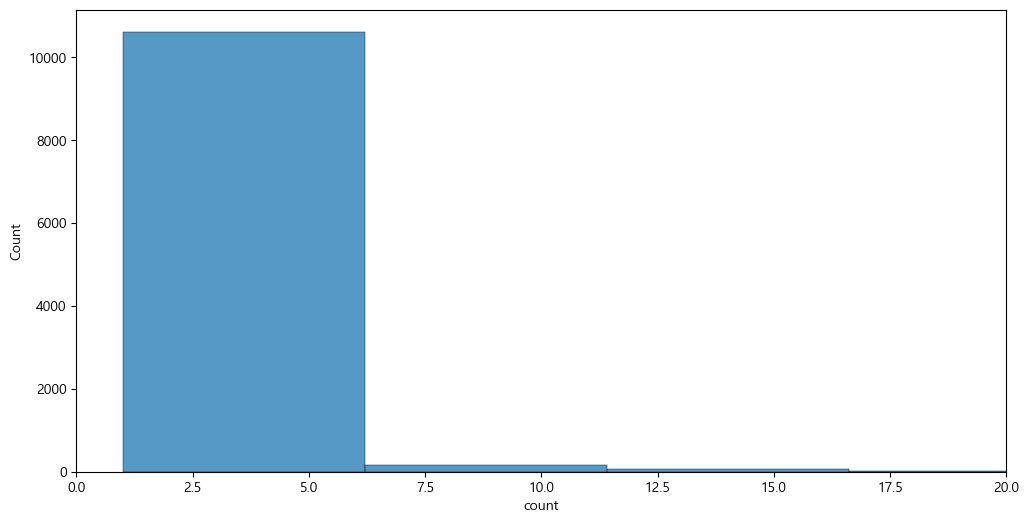

In [105]:
fig, axs = plt.subplots(1,1)



sns.histplot(df['host_id'].value_counts(),ax=axs)
axs.set_xlim(0,20)

In [114]:
for i in range(15):
    print(f'n={i+1} {(df['host_id'].value_counts()==i+1).sum()}')

n=1 8333
n=2 1365
n=3 504
n=4 226
n=5 105
n=6 86
n=7 62
n=8 36
n=9 38
n=10 25
n=11 12
n=12 15
n=13 9
n=14 12
n=15 9


In [117]:
for i in range(15):
    print(f'n={i+1} {(man_co['host_id'].value_counts()==i+1).sum()}')

n=1 64
n=2 31
n=3 20
n=4 23
n=5 6
n=6 10
n=7 4
n=8 4
n=9 3
n=10 1
n=11 2
n=12 0
n=13 0
n=14 0
n=15 1


In [120]:
(man_co['host_id'].value_counts()>100).sum()

np.int64(1)